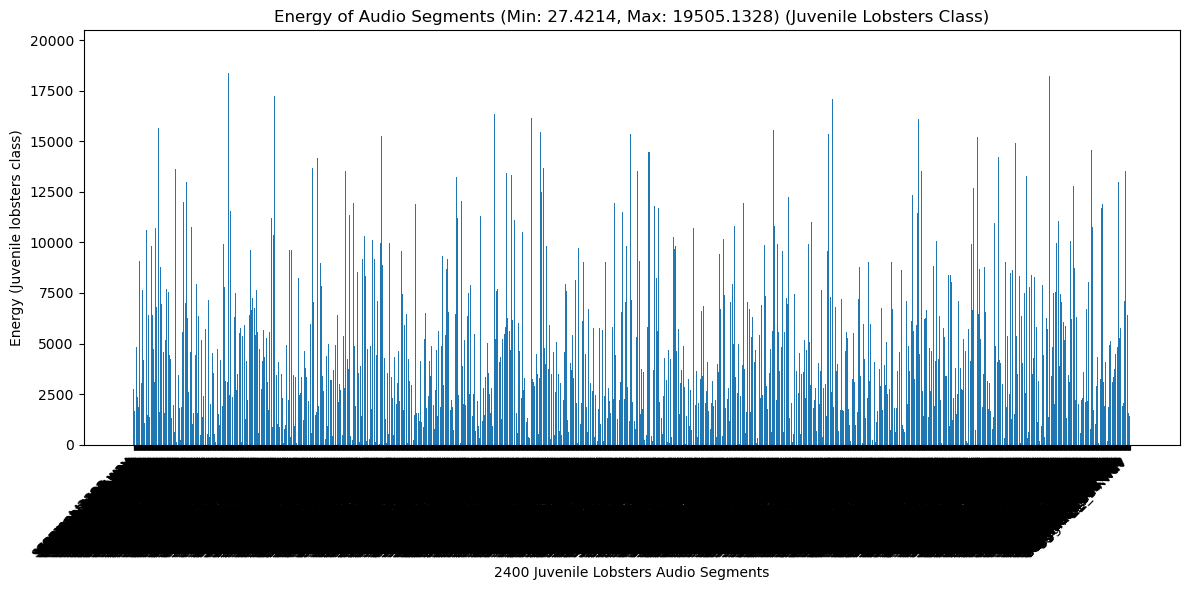

Minimum Energy: 27.421367645263672
Maximum Energy: 19505.1328125
Number of energies calculated: 2400


In [5]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import os

def calculate_and_plot_energy(audio_folder):
    """Calculates energy of audio segments, finds min/max, and plots.

    Args:
        audio_folder: Path to the folder containing audio files.
    """

    energies = []
    filenames = []

    for filename in os.listdir(audio_folder):
        if filename.endswith(('.wav', '.mp3', '.flac')):
            audio_file = os.path.join(audio_folder, filename)
            try:
                y, sr = librosa.load(audio_file, duration=1.0)

                if len(y) != sr:
                    print(f"Warning: {filename} is not exactly 1 second long. It is {len(y)/sr} seconds long")

                # Calculate energy: sum of squares
                energy = np.sum(y**2)  # or librosa.feature.rms(y=y)[0] for Root Mean Square energy
                energies.append(energy)
                filenames.append(filename)

            except Exception as e:
                print(f"Error processing {filename}: {e}")

    if not energies:
        print("No valid audio files found in the folder or errors occurred during processing.")
        return

    min_energy = np.min(energies)
    max_energy = np.max(energies)

    plt.figure(figsize=(12, 6))
    plt.bar(filenames, energies)
    plt.xlabel("2400 Juvenile Lobsters Audio Segments")  # Or make this more general
    plt.ylabel("Energy (Juvenile lobsters class)")  # Adapt the label
    plt.title(f"Energy of Audio Segments (Min: {min_energy:.4f}, Max: {max_energy:.4f}) (Juvenile Lobsters Class)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"Minimum Energy: {min_energy}")
    print(f"Maximum Energy: {max_energy}")
    return energies


# Example usage:
audio_folder = "/home/feliciano/juvenile_lobsters"
energies_returned = calculate_and_plot_energy(audio_folder)

if energies_returned is not None:
    print(f"Number of energies calculated: {len(energies_returned)}")
    # ... further processing of energies_returned ...